In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Ready")

Ready


In [2]:
# Download SPY and VIX
spy_raw = yf.download("SPY", start="2010-01-01",
                       end="2024-01-01", auto_adjust=True)
vix_raw = yf.download("^VIX", start="2010-01-01",
                       end="2024-01-01")

spy_raw.columns = spy_raw.columns.get_level_values(0)
vix_raw.columns = vix_raw.columns.get_level_values(0)

spy = spy_raw["Close"].squeeze()
vix = vix_raw["Close"].squeeze()

# Align both series
spy, vix = spy.align(vix, join="inner")

log_returns = np.log(spy / spy.shift(1)).dropna()

print(f"SPY observations : {len(spy)}")
print(f"VIX observations : {len(vix)}")
print(f"VIX current      : {vix.iloc[-1]:.2f}")
print(f"VIX mean         : {vix.mean():.2f}")
print(f"VIX max          : {vix.max():.2f}")
print(f"VIX min          : {vix.min():.2f}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

SPY observations : 3522
VIX observations : 3522
VIX current      : 12.45
VIX mean         : 18.57
VIX max          : 82.69
VIX min          : 9.14


VIX Regime Distribution:
  LOW        : 1270 days (36.1%)
  NORMAL     : 1733 days (49.2%)
  HIGH       :  423 days (12.0%)
  EXTREME    :   96 days (2.7%)


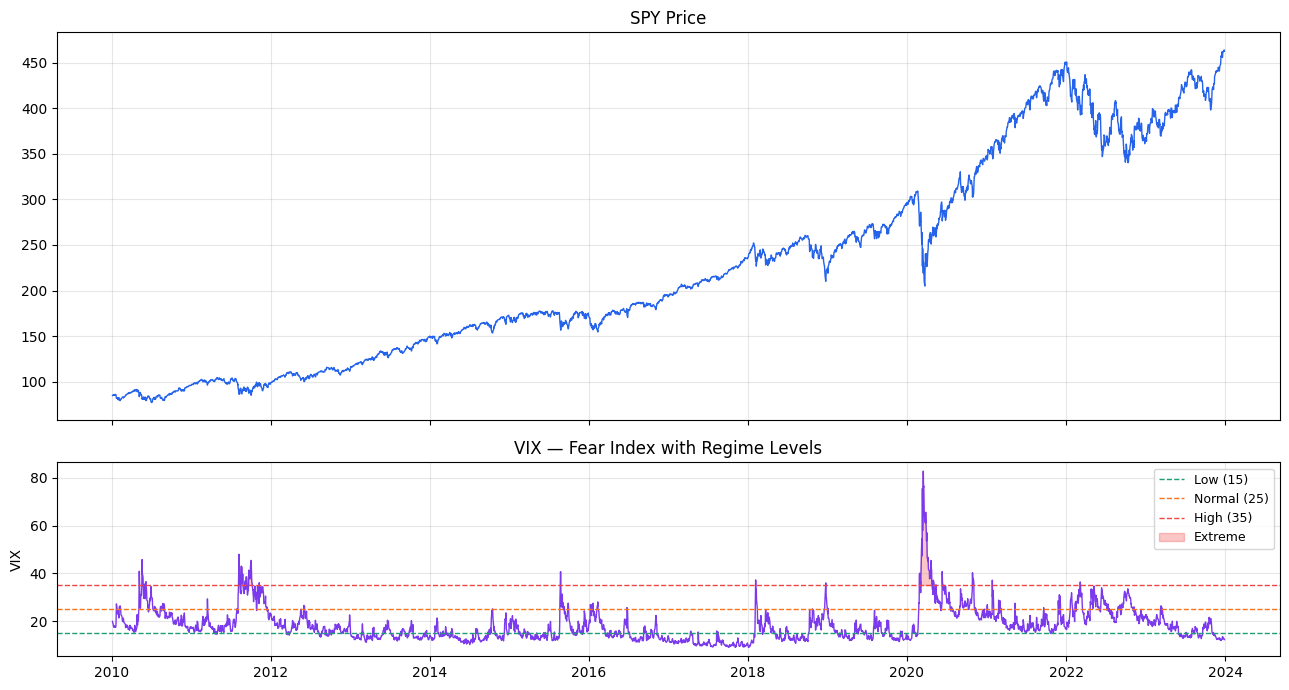

In [3]:
# Classify regimes
def vix_regime(v):
    if   v < 15: return "LOW"
    elif v < 25: return "NORMAL"
    elif v < 35: return "HIGH"
    else:        return "EXTREME"

regimes = vix.apply(vix_regime)

# Count days in each regime
print("VIX Regime Distribution:")
print("=" * 35)
for regime in ["LOW", "NORMAL", "HIGH", "EXTREME"]:
    count = (regimes == regime).sum()
    pct   = count / len(regimes) * 100
    print(f"  {regime:<10} : {count:>4} days ({pct:.1f}%)")
print("=" * 35)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

ax1.plot(spy, color='#2563eb', lw=1)
ax1.set_title('SPY Price')
ax1.grid(True, alpha=0.3)

# VIX with regime shading
ax2.plot(vix, color='#7c3aed', lw=1)
ax2.axhline(15, color='#1D9E75', lw=1,
            linestyle='--', label='Low (15)')
ax2.axhline(25, color='#f97316', lw=1,
            linestyle='--', label='Normal (25)')
ax2.axhline(35, color='#ef4444', lw=1,
            linestyle='--', label='High (35)')
ax2.fill_between(vix.index, vix, 35,
                 where=(vix > 35),
                 alpha=0.3, color='#ef4444',
                 label='Extreme')
ax2.set_title('VIX — Fear Index with Regime Levels')
ax2.set_ylabel('VIX')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# VIX contrarian strategy
vix_aligned = vix.reindex(log_returns.index).ffill()

pos_list, cp = [], 0
for i in range(len(vix_aligned)):
    if cp == 0 and vix_aligned.iloc[i] > 30:
        cp = 1
    elif cp == 1 and vix_aligned.iloc[i] < 20:
        cp = 0
    pos_list.append(cp)

position = pd.Series(pos_list,
                     index=log_returns.index).shift(1).fillna(0)
trades   = position.diff().abs().fillna(0)
net_ret  = position * log_returns - trades * 0.0006
equity   = (1 + net_ret).cumprod()
bh_eq    = (1 + log_returns).cumprod()

ar = net_ret.mean() * 252
av = net_ret.std()  * np.sqrt(252)
sh = (ar - 0.02)   / av
dd = (equity - equity.cummax()) / equity.cummax()

print(f"\n{'='*50}")
print(f"  VIX CONTRARIAN STRATEGY")
print(f"{'='*50}")
print(f"  Ann. Return    : {ar:.2%}")
print(f"  Ann. Volatility: {av:.2%}")
print(f"  Sharpe Ratio   : {sh:.2f}")
print(f"  Max Drawdown   : {dd.min():.2%}")
print(f"  Total trades   : {int(trades.sum())}")
print(f"  Time in market : {position.mean():.1%}")
print(f"{'='*50}")


  VIX CONTRARIAN STRATEGY
  Ann. Return    : 6.20%
  Ann. Volatility: 12.78%
  Sharpe Ratio   : 0.33
  Max Drawdown   : -30.21%
  Total trades   : 22
  Time in market : 19.1%



  Strategy                   Ann Ret  Ann Vol  Sharpe    Max DD
  Vol-Targeted SPY (10%)       8.58%   10.14%    0.65   -13.60%
  Buy & Hold SPY              12.14%   17.38%    0.58   -35.75%


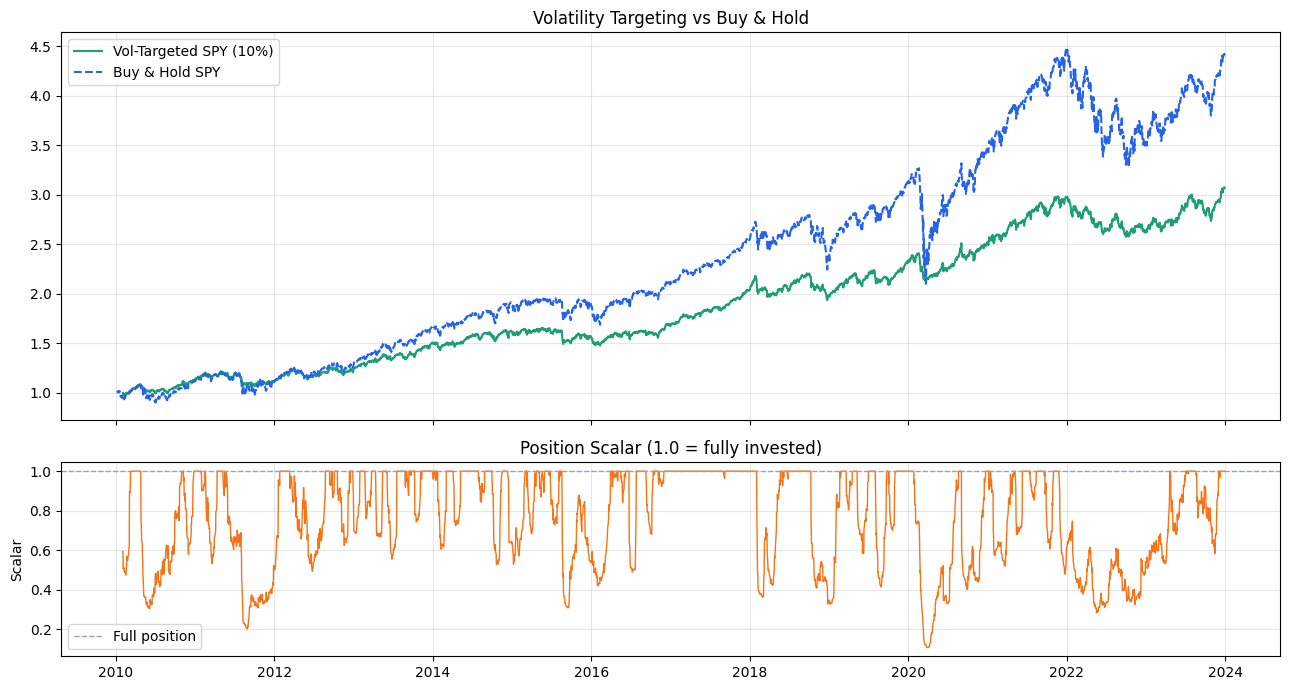

In [7]:
# Volatility targeting on SPY buy and hold
target_vol   = 0.10  # 10% annual volatility target
realized_vol = log_returns.rolling(20).std() * np.sqrt(252)

# Position scalar — reduce size in high vol, increase in low vol
vol_scalar = (target_vol / realized_vol).clip(0, 1)

# Apply scalar to returns (use previous day's vol estimate)
vt_returns = log_returns * vol_scalar.shift(1)

# Equity curves
vt_equity  = (1 + vt_returns).cumprod()
raw_equity = (1 + log_returns).cumprod()

# Metrics
def metrics(r, name):
    ar = r.mean() * 252
    av = r.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av
    w  = (1 + r).cumprod()
    dd = (w - w.cummax()) / w.cummax()
    print(f"  {name:<25} {ar:>8.2%} {av:>8.2%} {sh:>7.2f} {dd.min():>9.2%}")

print(f"\n{'='*62}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"{'='*62}")
metrics(vt_returns,  "Vol-Targeted SPY (10%)")
metrics(log_returns, "Buy & Hold SPY")
print(f"{'='*62}")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

ax1.plot(vt_equity,  color='#1D9E75', lw=1.5,
         label='Vol-Targeted SPY (10%)')
ax1.plot(raw_equity, color='#2563eb', lw=1.5,
         linestyle='--', label='Buy & Hold SPY')
ax1.set_title('Volatility Targeting vs Buy & Hold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(vol_scalar, color='#f97316', lw=1)
ax2.axhline(1.0, color='#94a3b8', lw=1,
            linestyle='--', label='Full position')
ax2.set_title('Position Scalar (1.0 = fully invested)')
ax2.set_ylabel('Scalar')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Combined strategy: VIX contrarian + vol targeting
vt_net = position * log_returns * vol_scalar.shift(1) - trades * 0.0006
vt_combined_eq = (1 + vt_net).cumprod()

ar_c = vt_net.mean() * 252
av_c = vt_net.std()  * np.sqrt(252)
sh_c = (ar_c - 0.02) / av_c
dd_c = (vt_combined_eq - vt_combined_eq.cummax()) / vt_combined_eq.cummax()

print(f"\n{'='*62}")
print(f"  {'Strategy':<25} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"{'='*62}")
metrics(vt_net,      "VIX + Vol Target")
metrics(net_ret,     "VIX Contrarian")
metrics(log_returns, "Buy & Hold SPY")
print(f"{'='*62}")


  Strategy                   Ann Ret  Ann Vol  Sharpe    Max DD
  VIX + Vol Target             3.08%    4.71%    0.23    -6.91%
  VIX Contrarian               6.20%   12.78%    0.33   -30.21%
  Buy & Hold SPY              12.14%   17.38%    0.58   -35.75%
